# 6장 실습 — 데이터 포맷과 직렬화

4장이 통계를, 5장이 남길 시연을 정했다. 이 노트북은 그 시연을 **어떤 모양으로 디스크에 둘 것인가**를 정한다.

재는 것은 둘이다.

1. **레이아웃** — 같은 시연 1,000판을 네 가지 형식으로 저장하고 용량·파일 수·쓰기 시간·첫 접근·무작위 접근·순차 처리량을 잰다
2. **손실 압축** — 관측과 행동을 몇 비트까지 줄여도 정책 성적이 버티는지 잰다

끝에서 5장이 남긴 `data/clean_v1.npz` 를 LeRobot v3 과 같은 모양의 폴더 `data/cell_v1/` 로 옮긴다. 3부가 이 폴더를 읽는다.

`pyarrow` 와 `h5py` 를 쓴다(Colab 에는 기본으로 깔려 있다).

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="sorting_cell">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="part" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
SEP, BX = .10, .28                      # 적재함 위치 (m)
MODEL = mujoco.MjModel.from_xml_string(XML)


def bin_xy(k):
    """A형(k=0)은 왼쪽, B형(k=1)은 오른쪽 적재함이다"""
    return np.array([BX, (1 - 2 * k) * SEP])


class Cell:
    """평면 분류 셀 — 부품을 종류에 맞는 칸으로 민다"""

    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.k = np.zeros(n, int)
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        self.k[i] = self.rng.integers(0, 2)
        jit = self.rng.uniform(-.03, .03, 2)
        self.g[i] = bin_xy(self.k[i]) + jit
        b = np.array([bx, by])
        v = self.g[i] - b
        d.qpos[7:9] = b - v / np.linalg.norm(v) * .09
        mujoco.mj_forward(self.m, d)
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.zeros((self.n, 10), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = (self.g[i] - b) * 10.
            o[i, 2:4] = d.qvel[0:2] * 10.
            o[i, 4:6] = (b - d.qpos[7:9]) * 10.
            o[i, 6:8] = d.qvel[6:8] * 10.
            o[i, 8 + self.k[i]] = 1.          # 종류 표시
        return o

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            hit = db < GOAL_R
            if hit or self.t[i] >= EP:
                dn[i] = 1.
                other = bin_xy(1 - self.k[i])
                wrong = np.linalg.norm(d.qpos[0:2] - other) < .06
                sc.append((int(hit), int(wrong), int(self.t[i]),
                           int(self.k[i])))
                self.reset(i)
        return r, dn, sc

In [4]:
class Pert(Cell):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("적재함 A", np.round(bin_xy(0), 2))
print("적재함 B", np.round(bin_xy(1), 2))
print("평가 조건:", ", ".join(COND))

적재함 A [0.28 0.1 ]
적재함 B [ 0.28 -0.1 ]
평가 조건: 명목, 배포


In [5]:
class AC(nn.Module):
    def __init__(self, din=10):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Cell(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 10), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 10))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac

In [6]:
import os
import csv
import json


def unit(v):
    n = np.linalg.norm(v, axis=-1, keepdims=True)
    return np.where(n > 1e-9, v / np.maximum(n, 1e-9), 0.)


def servo(env):
    """1장의 대본 전문가 — 부품 뒤로 돌아가 적재함 쪽으로 민다"""
    b = np.array([d.qpos[0:2] for d in env.d])
    p = np.array([d.qpos[7:9] for d in env.d])
    dv = unit(env.g - b)
    behind = b - dv * .045
    e = behind - p
    ne = np.linalg.norm(e, axis=1, keepdims=True)
    cmd = np.where(ne > .013, 14. * e, dv * .22)
    n = np.linalg.norm(cmd, axis=1, keepdims=True)
    cmd = np.where(n > .22, cmd / np.maximum(n, 1e-9) * .22, cmd)
    return np.clip(cmd / AMAX, -1, 1).astype(np.float32)


COLS = ["cond", "version", "seed", "kind", "success", "wrong",
        "steps"]


def rollout(actfn, cond, seed=999, n=150, reps=3, tag=0, ver="v0"):
    """1장의 로그 스키마 그대로 판마다 한 줄을 남긴다"""
    env = Pert(n, seed, **COND[cond])
    rows = []
    for t in range(EP * reps):
        _, dn, sc = env.step(actfn(env))
        for hit, wrong, steps, k in sc:
            rows.append((cond, ver, tag, "AB"[k], hit, wrong,
                         steps))
    return rows


def rate(rows):
    return sum(r[4] for r in rows) / len(rows)


def bc(X, Y, steps=4000, lr=1e-3, bs=512, seed=2):
    """행동 복제 — 관측에서 라벨로 가는 평균제곱 회귀"""
    torch.manual_seed(seed)
    net = AC(10)
    opt = torch.optim.Adam(net.pi.parameters(), lr)
    Xt = torch.from_numpy(X)
    Yt = torch.from_numpy(Y)
    g = torch.Generator().manual_seed(seed)
    for _ in range(steps):
        j = torch.randint(0, len(X), (bs,), generator=g)
        loss = ((net.pi(Xt[j]) - Yt[j]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
    return net


def mean_act(net):
    """평가는 평균 행동으로 — 복제 정책은 분산을 배우지 않았다"""
    def f(env):
        with torch.no_grad():
            return net.pi(torch.from_numpy(env.obs())).numpy()
    return f


def save_log(path, rows):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(COLS)
        w.writerows(rows)

In [7]:
import io
import shutil
import h5py
import pyarrow as pa
import pyarrow.parquet as pq

SIG = .22
if os.path.exists("data/collect.json"):
    SIG = json.load(open("data/collect.json")).get("sigma") or SIG


def episodes(count, seed, n=64):
    """잡음 주입 시연을 판 단위로 모은다"""
    rng = np.random.default_rng(seed)
    env = Cell(n, seed)
    cur = [[] for _ in range(n)]
    out = []
    while len(out) < count:
        o = env.obs()
        lab = servo(env)
        act = np.clip(lab + rng.normal(0, SIG, lab.shape), -1, 1)
        for i in range(n):
            cur[i].append((o[i], lab[i]))
        env_done = env.step(act.astype(np.float32))[1]
        for i in np.flatnonzero(env_done):
            o_ = np.array([a for a, _ in cur[i]], np.float32)
            a_ = np.array([b for _, b in cur[i]], np.float32)
            out.append((o_, a_))
            cur[i] = []
    return out[:count]


t0 = time.time()
EPS = episodes(1000, seed=11)
NSTEP = sum(len(o) for o, _ in EPS)
print(f"형식 비교용 시연 {len(EPS):,}판 · {NSTEP:,} 스텝 "
      f"({time.time() - t0:.0f}s)")

형식 비교용 시연 1,000판 · 46,101 스텝 (8s)


## 네 가지 레이아웃

로봇 학습 데이터에서 실제로 쓰이는 모양 넷을 고른다.

| 레이아웃 | 모양 | 쓰는 곳 |
|---|---|---|
| 판별 npz | 판 하나가 파일 하나 | 소규모 실험 (LeRobot v2 도 판마다 파일 하나) |
| HDF5 | 파일 하나 안에 판마다 그룹 | robomimic 계열 |
| Parquet | 모든 판을 한 표에, 판 경계는 메타 표에 | LeRobot v3 |
| JSON Lines | 스텝 하나가 한 줄 | 로그 수집기의 기본 출력 |

Parquet 쪽은 LeRobot v3 의 폴더 구조를 그대로 흉내 낸다 — `data/chunk-000/file-000.parquet` 에 스텝이, `meta/episodes/…parquet` 에 판의 시작과 끝이, `meta/info.json` 과 `meta/stats.json` 에 형식과 통계가 들어간다.

In [8]:
ROOT = "fmt"
shutil.rmtree(ROOT, ignore_errors=True)
os.makedirs(ROOT)


def du(p):
    if os.path.isfile(p):
        return os.path.getsize(p), 1
    s = n = 0
    for r, _, fs in os.walk(p):
        for f in fs:
            s += os.path.getsize(os.path.join(r, f))
            n += 1
    return s, n


def w_npz(E):
    d = f"{ROOT}/npz_ep"
    os.makedirs(d)
    for i, (o, a) in enumerate(E):
        np.savez(f"{d}/ep_{i:06d}.npz", obs=o, act=a)
    return d


def r_npz(d):
    def get(i):
        z = np.load(f"{d}/ep_{i:06d}.npz")
        return z["obs"], z["act"]
    return get


def w_h5(E):
    p = f"{ROOT}/demos.hdf5"
    with h5py.File(p, "w") as f:
        g = f.create_group("data")
        for i, (o, a) in enumerate(E):
            e = g.create_group(f"demo_{i}")
            e.create_dataset("obs", data=o)
            e.create_dataset("actions", data=a)
    return p


def r_h5(p):
    f = h5py.File(p, "r")

    def get(i):
        e = f["data"][f"demo_{i}"]
        return e["obs"][()], e["actions"][()]
    return get


def to_table(E):
    O = np.concatenate([o for o, _ in E])
    A = np.concatenate([a for _, a in E])
    ep = np.concatenate([np.full(len(o), i)
                         for i, (o, _) in enumerate(E)])
    fr = np.concatenate([np.arange(len(o)) for o, _ in E])
    fl = pa.FixedSizeListArray.from_arrays
    return pa.table({
        "episode_index": ep, "frame_index": fr,
        "observation.state": fl(pa.array(O.ravel()), O.shape[1]),
        "action": fl(pa.array(A.ravel()), A.shape[1])}), O


def w_lerobot(E, d=None, stats=None):
    d = d or f"{ROOT}/lerobot"
    os.makedirs(f"{d}/data/chunk-000", exist_ok=True)
    os.makedirs(f"{d}/meta/episodes/chunk-000", exist_ok=True)
    tbl, O = to_table(E)
    pq.write_table(tbl, f"{d}/data/chunk-000/file-000.parquet")
    lens = np.array([len(o) for o, _ in E])
    start = np.concatenate([[0], np.cumsum(lens)[:-1]])
    pq.write_table(pa.table({"episode_index": np.arange(len(E)),
                             "length": lens, "from": start,
                             "to": start + lens}),
                   f"{d}/meta/episodes/chunk-000/file-000.parquet")
    info = {"codebase_version": "v3.0-like", "fps": 20,
            "total_episodes": len(E),
            "total_frames": int(lens.sum()),
            "features": {"observation.state": [O.shape[1]],
                         "action": [2]}}
    json.dump(info, open(f"{d}/meta/info.json", "w"), indent=1)
    st = stats or {"observation.state": {"mean": O.mean(0).tolist(),
                                         "std": O.std(0).tolist()}}
    with open(f"{d}/meta/stats.json", "w") as f:
        json.dump(st, f, ensure_ascii=False, indent=1)
    return d


def r_lerobot(d):
    t = pq.read_table(f"{d}/data/chunk-000/file-000.parquet",
                      memory_map=True)
    m = pq.read_table(f"{d}/meta/episodes/chunk-000/"
                      "file-000.parquet").to_pandas()
    so, sa = t["observation.state"], t["action"]

    def get(i):
        a, b = int(m["from"][i]), int(m["to"][i])
        o = so.slice(a, b - a).combine_chunks().flatten()
        c = sa.slice(a, b - a).combine_chunks().flatten()
        return (np.asarray(o).reshape(b - a, -1),
                np.asarray(c).reshape(b - a, 2))
    return get


def w_jsonl(E):
    p = f"{ROOT}/steps.jsonl"
    with open(p, "w") as f:
        for i, (o, a) in enumerate(E):
            for t in range(len(o)):
                f.write(json.dumps({"ep": i, "t": t,
                                    "obs": o[t].tolist(),
                                    "act": a[t].tolist()}) + "\n")
    return p


def r_jsonl(p):
    idx = {}              # 판을 찾으려면 파일 전체를 읽어야 한다
    for line in open(p):
        r = json.loads(line)
        idx.setdefault(r["ep"], []).append(r)

    def get(i):
        rs = idx[i]
        return (np.array([r["obs"] for r in rs], np.float32),
                np.array([r["act"] for r in rs], np.float32))
    return get


FMT = [("판별 npz", w_npz, r_npz), ("HDF5", w_h5, r_h5),
       ("Parquet", w_lerobot, r_lerobot),
       ("JSON Lines", w_jsonl, r_jsonl)]
rng = np.random.default_rng(0)
IDX = rng.integers(0, len(EPS), 300)
BENCH = {}
for nm, w, r in FMT:
    t = time.time()
    p = w(EPS)
    t_w = time.time() - t
    size, nfile = du(p)
    t = time.time()
    get = r(p)
    get(0)
    t_open = time.time() - t
    t = time.time()
    for i in IDX:
        o, a = get(int(i))
        assert np.array_equal(a, EPS[i][1])
    t_rand = (time.time() - t) / len(IDX)
    t = time.time()
    n = sum(len(get(i)[0]) for i in range(len(EPS)))
    t_seq = time.time() - t
    BENCH[nm] = (size, nfile, t_w, t_open, t_rand, n / t_seq)

print(pad("레이아웃", 12) + pad("용량 MB", 9, True)
      + pad("파일", 6, True) + pad("쓰기 s", 8, True)
      + pad("첫 접근 ms", 12, True) + pad("판당 ms", 9, True) + pad("스텝/s", 11, True))
for nm, (sz, nf, tw, to, tr, th) in BENCH.items():
    print(pad(nm, 12) + pad(f"{sz / 1e6:.2f}", 9, True)
          + pad(nf, 6, True) + pad(f"{tw:.2f}", 8, True)
          + pad(f"{to * 1e3:.1f}", 12, True)
          + pad(f"{tr * 1e3:.3f}", 9, True)
          + pad(f"{th / 1e3:,.0f}k", 11, True))

레이아웃      용량 MB  파일  쓰기 s  첫 접근 ms  판당 ms     스텝/s
판별 npz         2.71  1000    0.16         1.0    0.223       163k
HDF5             3.94     1    0.33         1.1    0.381       143k
Parquet          2.73     4    0.25        27.1    0.113       514k
JSON Lines      11.69     1    0.41       396.2    0.043     1,464k


## 손실 압축 곡선

저장 용량을 더 줄이려면 값을 덜 정밀하게 적어야 한다. 관측 여덟 차원과 행동 두 차원을 b 비트 정수로 양자화해 저장하고, **그 데이터로 학습한 정책을 원래의 실수 관측으로 굴린다.** 실기에서는 저장만 거칠게 하고 센서는 그대로이기 때문이다.

관측의 양자화 범위는 4장과 같은 방식의 q01·q99(이 1,000판에서 다시 낸다)이고, 행동은 [−1, 1]이다. 용량은 압축한 npz 로 잰다. 시드 셋, 배포 조건이다.

In [9]:
O_ALL = np.concatenate([o for o, _ in EPS])
A_ALL = np.concatenate([a for _, a in EPS])
QLO = np.percentile(O_ALL[:, :8], 1, 0)
QHI = np.percentile(O_ALL[:, :8], 99, 0)


def quant(Z, lo, hi, b):
    top = 2 ** b - 1
    q = np.clip(np.round((Z - lo) / (hi - lo) * top), 0, top)
    code = q.astype(np.uint8 if b <= 8 else np.uint16)
    return code, q / top * (hi - lo) + lo


def nbytes(**kw):
    f = io.BytesIO()
    np.savez_compressed(f, **kw)
    return f.tell()


BITS = (32, 16, 8, 6, 4, 3)
SEEDS = (0, 1, 2)
LOSSY, LOG = {}, []
t0 = time.time()
for b in BITS:
    if b == 32:
        Xq, Yq = O_ALL, A_ALL
        sz = nbytes(o=O_ALL, a=A_ALL)
    elif b == 16:
        Xq = O_ALL.astype(np.float16).astype(np.float32)
        Yq = A_ALL.astype(np.float16).astype(np.float32)
        sz = nbytes(o=O_ALL.astype(np.float16),
                    a=A_ALL.astype(np.float16))
    else:
        qo, xo = quant(O_ALL[:, :8], QLO, QHI, b)
        qa, Yq = quant(A_ALL, -1., 1., b)
        Xq = np.concatenate([xo, O_ALL[:, 8:]], 1)
        sz = nbytes(o=qo, a=qa,
                    k=O_ALL[:, 8:].argmax(1).astype(np.uint8))
    err = np.abs(Yq - A_ALL).max()
    rs = []
    for s in SEEDS:
        net = bc(Xq.astype(np.float32), Yq.astype(np.float32),
                 seed=s)
        rows = rollout(mean_act(net), "배포", tag=s, ver=f"bits{b}",
                       n=100, reps=2)
        LOG += rows
        rs.append(rate(rows))
    LOSSY[b] = (sz, err, rs)
    dt = time.time() - t0
    print(f"  {b:>2} 비트 끝  ({dt:.0f}s)", flush=True)

print()
print(pad("비트", 6) + pad("용량 MB", 9, True)
      + pad("행동 최대 오차", 15, True) + pad("배포 성공", 11, True)
      + pad("범위", 15, True))
for b, (sz, err, rs) in LOSSY.items():
    print(pad(b, 6) + pad(f"{sz / 1e6:.2f}", 9, True)
          + pad(f"{err:.4f}", 15, True)
          + pad(f"{np.mean(rs):.3f}", 11, True)
          + pad(f"[{min(rs):.2f}, {max(rs):.2f}]", 15, True))

  32 비트 끝  (30s)


  16 비트 끝  (58s)


   8 비트 끝  (86s)


   6 비트 끝  (116s)


   4 비트 끝  (144s)


   3 비트 끝  (174s)



비트    용량 MB 행동 최대 오차  배포 성공           범위
32         1.74         0.0000      0.946   [0.93, 0.97]
16         0.85         0.0002      0.950   [0.92, 0.98]
8          0.40         0.0039      0.952   [0.92, 0.98]
6          0.30         0.0159      0.945   [0.92, 0.98]
4          0.20         0.0667      0.872   [0.80, 0.92]
3          0.14         0.1429      0.636   [0.45, 0.81]


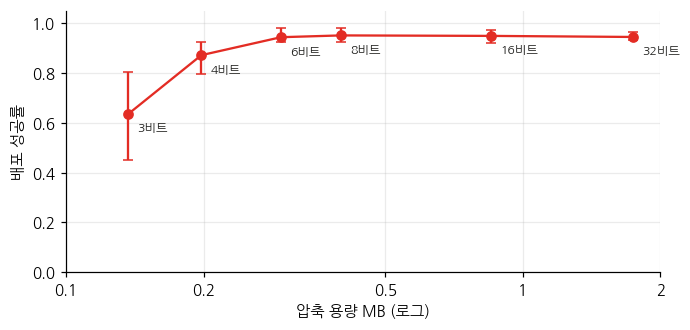

In [10]:
fig, ax = plt.subplots(figsize=(6.4, 3.1))
sz = np.array([LOSSY[b][0] for b in BITS]) / 1e6
m = np.array([np.mean(LOSSY[b][2]) for b in BITS])
lo = m - np.array([min(LOSSY[b][2]) for b in BITS])
hi = np.array([max(LOSSY[b][2]) for b in BITS]) - m
ax.errorbar(sz, m, yerr=[lo, hi], color=RED, marker="o", capsize=3)
for b, x, y in zip(BITS, sz, m):
    ax.annotate(f"{b}비트", (x, y), textcoords="offset points",
                xytext=(6, -12), fontsize=8, color=INK)
ax.set_xscale("log")
ax.set_xticks([.1, .2, .5, 1, 2])
ax.set_xticklabels(["0.1", "0.2", "0.5", "1", "2"])
ax.minorticks_off()
ax.set_xlabel("압축 용량 MB (로그)")
ax.set_ylabel("배포 성공률")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3부로 넘길 데이터셋

5장이 남긴 시연을 Parquet 레이아웃으로 옮긴다. `meta/stats.json` 에는 4장의 정규화 통계를 그대로 넣는다 — 학습 코드가 데이터와 통계를 한 폴더에서 읽게 하기 위해서다. 옮긴 뒤 다시 읽어 원본과 한 비트도 다르지 않은지 확인한다.

In [11]:
if os.path.exists("data/clean_v1.npz"):
    C = np.load("data/clean_v1.npz")
    lens = C["lengths"]
    cut = np.concatenate([[0], np.cumsum(lens)])
    CLEAN = [(C["X"][a:b], C["Y"][a:b])
             for a, b in zip(cut[:-1], cut[1:])]
    print(f"5장이 남긴 data/clean_v1.npz — {len(CLEAN)}판")
else:
    CLEAN = episodes(128, seed=1)
    print("data/clean_v1.npz 가 없다 — 좋은 시연 128판을 모았다")

STATS = None
if os.path.exists("data/norm_stats.json"):
    ns = json.load(open("data/norm_stats.json"))
    STATS = {"observation.state": ns}
out = "data/cell_v1"
shutil.rmtree(out, ignore_errors=True)
w_lerobot(CLEAN, out, STATS)
get = r_lerobot(out)
same = all(np.array_equal(get(i)[0], o)
           and np.array_equal(get(i)[1], a)
           for i, (o, a) in enumerate(CLEAN))
size, nfile = du(out)
save_log("report/ch06_log.csv", LOG)
print(f"왕복 검사: {'일치' if same else '불일치'}")
print()
print("남긴 산출물")
print(f"  data/cell_v1/         {len(CLEAN)}판 · 파일 {nfile}개 · "
      f"{size / 1e3:.0f} kB")
for r, _, fs in sorted(os.walk(out)):
    for f in sorted(fs):
        print("    " + os.path.join(r, f)[len(out) + 1:])
print(f"  report/ch06_log.csv   판별 로그 {len(LOG):,}줄")

5장이 남긴 data/clean_v1.npz — 128판


왕복 검사: 일치

남긴 산출물
  data/cell_v1/         128판 · 파일 4개 · 356 kB
    data/chunk-000/file-000.parquet
    meta/info.json
    meta/stats.json
    meta/episodes/chunk-000/file-000.parquet
  report/ch06_log.csv   판별 로그 6,627줄


## 정리

**형식은 접근 방식으로 고른다.** 판 하나를 자주 꺼내면 판별 파일도 괜찮다. 학습처럼 여러 판을 순서대로 읽으면 Parquet 한 파일이 세 배 빠르다. JSON Lines 는 수집기의 출력으로는 편하지만 용량이 4.3배이고 판을 찾으려면 전부 읽어야 한다.

**6비트까지는 손실 압축이 공짜였다.** 용량이 여섯 배 가까이 줄어도 배포 성공률이 그대로다. 4비트부터 성적이 무너진다.

**3부로 넘기는 것은 `data/cell_v1/` 이다.** 5장이 남긴 128판을 LeRobot v3 와 같은 폴더 구조로 옮기고, 4장의 정규화 통계를 `meta/stats.json` 에 넣었다. 다시 읽어 원본과 비트 단위로 일치하는 것을 확인했다.